Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)

Displaying sample MNIST images...


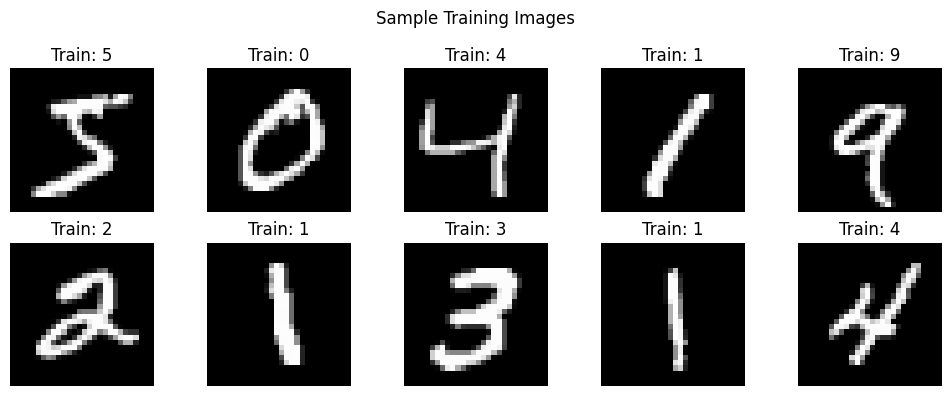

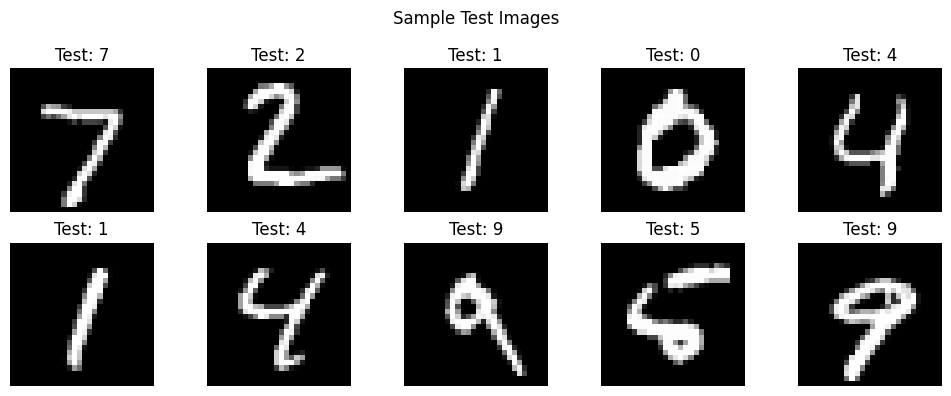



DESIGN SPACE
Hidden layers: [1, 2, 3]
Nodes/layer  : [10, 20, 40, 80, 160, 200]
Total configurations: 18


Configuration 1/18
Architecture: layers=1, nodes=10
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8592 - loss: 0.5039
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9184 - loss: 0.2879
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9263 - loss: 0.2617
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9310 - loss: 0.2467
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9337 - loss: 0.2364

Test accuracy = 93.36%
Accuracy drop = 6.64%
Parameters = 7,960


Configuration 2/18
Architecture: layers=1, nodes=20
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8830 - loss: 0.4146
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9323 - loss: 0.2395
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9414 - loss: 0.2020
Epoch 4/5
1875/1875 ━━━━

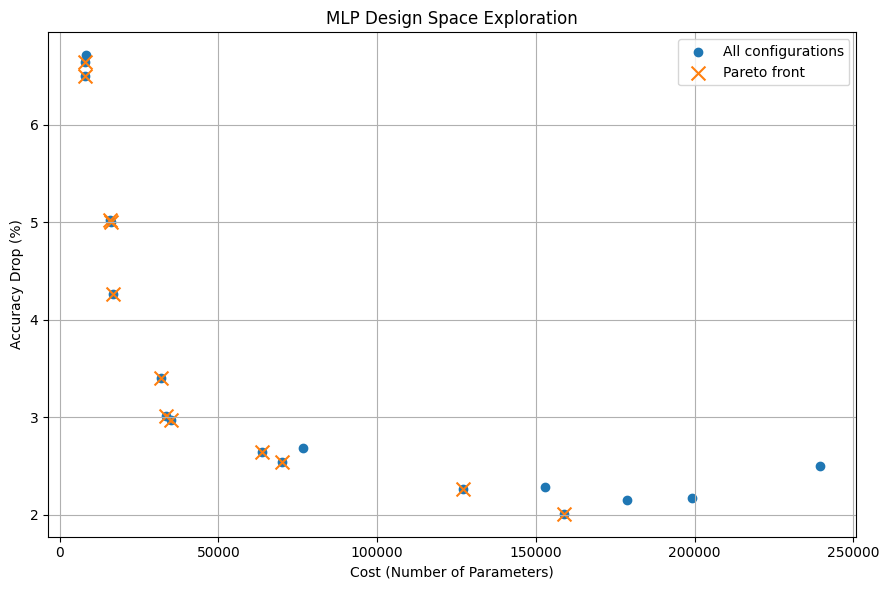

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# TASK 1: LOAD MNIST DATASET
# ============================================================

def load_mnist():

    print("Loading MNIST dataset...")

    (x_train, y_train), (x_test, y_test) = (
        tf.keras.datasets.mnist.load_data()
    )

    # Normalize pixel values from [0, 255] to [0, 1]
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0

    print("Training images:", x_train.shape)
    print("Training labels:", y_train.shape)
    print("Testing images :", x_test.shape)
    print("Testing labels :", y_test.shape)

    return x_train, y_train, x_test, y_test


# ============================================================
# TASK 1: DISPLAY MNIST TRAINING AND TEST IMAGES
# ============================================================

def show_mnist_samples(x_train, y_train, x_test, y_test):

    # --------------------------------------------------------
    # Display training images
    # --------------------------------------------------------

    plt.figure(figsize=(10, 4))

    for i in range(10):

        plt.subplot(2, 5, i + 1)

        plt.imshow(x_train[i], cmap="gray")

        plt.title(f"Train: {y_train[i]}")

        plt.axis("off")

    plt.suptitle("Sample Training Images")

    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # Display test images
    # --------------------------------------------------------

    plt.figure(figsize=(10, 4))

    for i in range(10):

        plt.subplot(2, 5, i + 1)

        plt.imshow(x_test[i], cmap="gray")

        plt.title(f"Test: {y_test[i]}")

        plt.axis("off")

    plt.suptitle("Sample Test Images")

    plt.tight_layout()

    plt.show()


# ============================================================
# TASK 1: PARAMETERIZABLE MLP GENERATOR
# ============================================================

def build_model(num_layers, nodes_per_layer):

    model = tf.keras.Sequential()

    # Input: MNIST image = 28 x 28
    model.add(
        tf.keras.layers.Input(shape=(28, 28))
    )

    # Convert 28 x 28 image into a vector of 784 values
    model.add(
        tf.keras.layers.Flatten()
    )

    # --------------------------------------------------------
    # Add hidden layers programmatically
    # --------------------------------------------------------

    # First hidden layer
    model.add(
        tf.keras.layers.Dense(
            nodes_per_layer,
            activation="relu"
        )
    )

    # Remaining hidden layers
    for _ in range(num_layers - 1):

        model.add(
            tf.keras.layers.Dense(
                nodes_per_layer,
                activation="relu"
            )
        )

    # --------------------------------------------------------
    # Output layer
    # MNIST has 10 classes: digits 0 to 9
    # --------------------------------------------------------

    model.add(
        tf.keras.layers.Dense(
            10,
            activation="softmax"
        )
    )

    return model


# ============================================================
# TASK 2: FIND PARETO FRONT
# ============================================================

def find_pareto_front(results):

    pareto_results = []

    for current in results:

        dominated = False

        # Compare current configuration
        # with every other configuration
        for other in results:

            if other == current:
                continue

            # ------------------------------------------------
            # Other configuration has no worse cost
            # and no worse accuracy drop
            # ------------------------------------------------

            cost_is_no_worse = (
                other["parameters"] <= current["parameters"]
            )

            accuracy_is_no_worse = (
                other["accuracy_drop"] <= current["accuracy_drop"]
            )

            # ------------------------------------------------
            # Other configuration must be strictly better
            # in at least one objective
            # ------------------------------------------------

            actually_better = (
                other["parameters"] < current["parameters"]
                or
                other["accuracy_drop"] < current["accuracy_drop"]
            )

            # If both conditions are satisfied,
            # current configuration is dominated
            if cost_is_no_worse and accuracy_is_no_worse and actually_better:

                dominated = True

                break

        # If nobody dominates current,
        # it belongs to the Pareto front
        if not dominated:

            pareto_results.append(current)

    return pareto_results


# ============================================================
# TASK 2: MAIN DSE
# ============================================================

def main():

    # ========================================================
    # STEP 1: LOAD DATASET
    # ========================================================

    x_train, y_train, x_test, y_test = load_mnist()


    # ========================================================
    # STEP 2: DISPLAY DATASET SAMPLES
    # ========================================================

    print("\nDisplaying sample MNIST images...")

    show_mnist_samples(
        x_train,
        y_train,
        x_test,
        y_test
    )


    # ========================================================
    # STEP 3: FIXED TRAINING SETTINGS
    # ========================================================

    # These settings remain the same for
    # every architecture.

    epochs = 5
    batch_size = 32
    learning_rate = 0.001


    # ========================================================
    # STEP 4: DEFINE DESIGN SPACE
    # ========================================================

    # Number of hidden layers:
    # 1, 2, or 3

    layer_options = [1, 2, 3]


    # Nodes per hidden layer:
    # logarithmically spaced approximately from 10 to 200

    node_options = [10, 20, 40, 80, 160, 200]


    # Total number of configurations

    total_configurations = (
        len(layer_options) *
        len(node_options)
    )

    print("\n")
    print("=" * 70)
    print("DESIGN SPACE")
    print("=" * 70)

    print("Hidden layers:", layer_options)
    print("Nodes/layer  :", node_options)

    print(
        "Total configurations:",
        total_configurations
    )


    # ========================================================
    # STEP 5: EXHAUSTIVE DESIGN SPACE EXPLORATION
    # ========================================================

    results = []

    configuration_number = 0

    for num_layers in layer_options:

        for nodes_per_layer in node_options:

            configuration_number += 1

            print("\n")
            print("=" * 70)

            print(
                f"Configuration "
                f"{configuration_number}/{total_configurations}"
            )

            print(
                f"Architecture: "
                f"layers={num_layers}, "
                f"nodes={nodes_per_layer}"
            )

            print("=" * 70)


            # ------------------------------------------------
            # Build model
            # ------------------------------------------------

            model = build_model(
                num_layers,
                nodes_per_layer
            )


            # ------------------------------------------------
            # Create optimizer
            # ------------------------------------------------

            optimizer = tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            )


            # ------------------------------------------------
            # Compile model
            # ------------------------------------------------

            model.compile(
                optimizer=optimizer,
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )


            # ------------------------------------------------
            # Train model
            # ------------------------------------------------

            model.fit(
                x_train,
                y_train,
                epochs=epochs,
                batch_size=batch_size,
                verbose=1
            )


            # ------------------------------------------------
            # Evaluate model on TEST dataset
            # ------------------------------------------------

            test_loss, test_accuracy = model.evaluate(
                x_test,
                y_test,
                verbose=0
            )


            # ------------------------------------------------
            # Calculate implementation cost
            #
            # We use total number of trainable parameters
            # as the cost proxy.
            # ------------------------------------------------

            num_parameters = model.count_params()


            # ------------------------------------------------
            # Calculate accuracy drop
            #
            # Accuracy drop = 100% - test accuracy (%)
            # ------------------------------------------------

            accuracy_drop = (
                1 - test_accuracy
            ) * 100


            # ------------------------------------------------
            # Store results
            # ------------------------------------------------

            results.append({

                "layers": num_layers,

                "nodes": nodes_per_layer,

                "parameters": num_parameters,

                "test_loss": test_loss,

                "test_accuracy": test_accuracy,

                "accuracy_drop": accuracy_drop
            })


            # ------------------------------------------------
            # Print configuration result
            # ------------------------------------------------

            print(
                f"\nTest accuracy = "
                f"{test_accuracy * 100:.2f}%"
            )

            print(
                f"Accuracy drop = "
                f"{accuracy_drop:.2f}%"
            )

            print(
                f"Parameters = "
                f"{num_parameters:,}"
            )


    # ========================================================
    # STEP 6: PRINT ALL DSE RESULTS
    # ========================================================

    print("\n\n")

    print("=" * 90)
    print("FINAL DSE RESULTS")
    print("=" * 90)

    print(
        f"{'Layers':>8}"
        f"{'Nodes':>8}"
        f"{'Parameters':>15}"
        f"{'Accuracy':>15}"
        f"{'Accuracy Drop':>18}"
    )

    print("-" * 90)


    for result in results:

        print(
            f"{result['layers']:>8}"
            f"{result['nodes']:>8}"
            f"{result['parameters']:>15,}"
            f"{result['test_accuracy'] * 100:>14.2f}%"
            f"{result['accuracy_drop']:>17.2f}%"
        )


    # ========================================================
    # STEP 7: FIND PARETO FRONT
    # ========================================================

    pareto_results = find_pareto_front(results)


    # ========================================================
    # STEP 8: PRINT PARETO RESULTS
    # ========================================================

    print("\n\n")

    print("=" * 90)
    print("PARETO-OPTIMAL CONFIGURATIONS")
    print("=" * 90)

    print(
        f"{'Layers':>8}"
        f"{'Nodes':>8}"
        f"{'Parameters':>15}"
        f"{'Accuracy':>15}"
        f"{'Accuracy Drop':>18}"
    )

    print("-" * 90)


    for result in pareto_results:

        print(
            f"{result['layers']:>8}"
            f"{result['nodes']:>8}"
            f"{result['parameters']:>15,}"
            f"{result['test_accuracy'] * 100:>14.2f}%"
            f"{result['accuracy_drop']:>17.2f}%"
        )


    # ========================================================
    # STEP 9: PREPARE DATA FOR PLOT
    # ========================================================

    costs = [
        result["parameters"]
        for result in results
    ]

    accuracy_drops = [
        result["accuracy_drop"]
        for result in results
    ]


    pareto_costs = [
        result["parameters"]
        for result in pareto_results
    ]

    pareto_accuracy_drops = [
        result["accuracy_drop"]
        for result in pareto_results
    ]


    # ========================================================
    # STEP 10: PLOT DESIGN SPACE AND PARETO FRONT
    # ========================================================

    plt.figure(figsize=(9, 6))


    # All configurations
    plt.scatter(
        costs,
        accuracy_drops,
        label="All configurations"
    )


    # Pareto configurations
    plt.scatter(
        pareto_costs,
        pareto_accuracy_drops,
        marker="x",
        s=100,
        label="Pareto front"
    )


    # Labels
    plt.xlabel(
        "Cost (Number of Parameters)"
    )

    plt.ylabel(
        "Accuracy Drop (%)"
    )

    plt.title(
        "MLP Design Space Exploration"
    )


    plt.grid(True)

    plt.legend()

    plt.tight_layout()


    # Save figure
    plt.savefig(
        "pareto_front.png",
        dpi=300
    )

    plt.show()


# ============================================================
# PROGRAM ENTRY POINT
# ============================================================

if __name__ == "__main__":

    main()